# 📓 Problem 5: Handwriting Recognition Using Deep Learning Using Real Data — The MNIST Dataset

In [1]:
# ============================================================
# Check Whether GPU is Enabled in Google Colab
# ============================================================

import torch

print("Checking GPU availability...\n")

if torch.cuda.is_available():

    print("✅ GPU is ENABLED!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

else:

    print("❌ GPU is NOT enabled.")
    print("\nTo enable GPU in Google Colab:")
    print("1. Click 'Runtime' in the top menu")
    print("2. Select 'Change runtime type'")
    print("3. Set Hardware Accelerator to 'GPU'")
    print("4. Click 'Save'")
    print("\nThen restart the notebook and run this cell again.")

Checking GPU availability...

✅ GPU is ENABLED!
GPU Name: Tesla T4


In [2]:
# ============================================================
# Problem 5: Handwriting Recognition Using Deep Learning
# Using the MNIST Dataset
# ============================================================

# ============================================================
# Step 1: Import Required Libraries
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt



# 🧠 Step 1: Import Required Libraries

In this project, we use PyTorch and TorchVision to build a handwritten digit recognition system using the famous MNIST dataset.

The imported libraries serve the following purposes:

| Library | Purpose |
|---|---|
| `torch` | Core PyTorch tensor operations |
| `torch.nn` | Neural network layers |
| `torch.optim` | Optimization algorithms like Adam |
| `torchvision.datasets` | Loads the MNIST dataset |
| `torchvision.transforms` | Image preprocessing |
| `DataLoader` | Loads data in mini-batches |
| `matplotlib` | Visualizes training loss |


In [3]:

# ============================================================
# Step 2: Define Image Transformations
# ============================================================

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])



# 🔄 Step 2: Define Image Transformations

Neural networks perform better when image data is normalized.

The transformation pipeline performs two important operations:

## 1. `transforms.ToTensor()`

This converts each image into a PyTorch tensor and scales pixel values:

| Original Range | New Range |
|---|---|
| 0 → 255 | 0.0 → 1.0 |

---

## 2. `transforms.Normalize((0.5,), (0.5,))`

This further rescales the values into the range:

[-1, 1]

This normalization helps:
- faster convergence
- stable gradients
- improved learning


In [4]:

# ============================================================
# Step 3: Load the MNIST Dataset
# ============================================================

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training Images:")
print(len(train_dataset))

print("\nTesting Images:")
print(len(test_dataset))


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.86MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.17MB/s]

Training Images:
60000

Testing Images:
10000


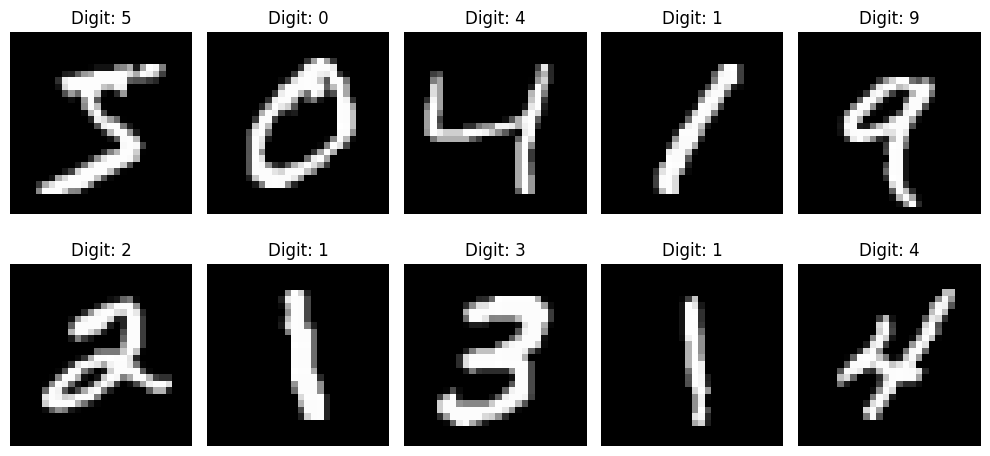

In [14]:
# ============================================================
# Display Sample Images from MNIST Dataset
# ============================================================

# Create figure
plt.figure(figsize=(10, 5))

# Display first 10 images
for i in range(10):

    image, label = train_dataset[i]

    plt.subplot(2, 5, i + 1)

    # Remove channel dimension for visualization
    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(f"Digit: {label}")

    plt.axis("off")

plt.tight_layout()

plt.show()


# 📂 Step 3: Load the MNIST Dataset

MNIST contains:

| Dataset | Number of Images |
|---|---|
| Training Set | 60,000 |
| Test Set | 10,000 |

Each image:
- is grayscale
- has size 28 × 28 pixels
- represents a digit from 0 → 9

TorchVision automatically downloads the dataset if it does not already exist locally.


In [5]:

# ============================================================
# Step 4: Create DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)



# 📦 Step 4: Create DataLoaders

DataLoaders efficiently load data in mini-batches.

## Why Use Mini-Batches?

Instead of training on all 60,000 images at once:
- memory usage stays low
- training becomes faster
- gradients become more stable


In [6]:

# ============================================================
# Step 5: Build the Neural Network
# ============================================================

class MNISTClassifier(nn.Module):

    def __init__(self):

        super(MNISTClassifier, self).__init__()

        self.flatten_layer = nn.Flatten()

        self.input_to_hidden1 = nn.Linear(
            784,
            128
        )

        self.relu_activation1 = nn.ReLU()

        self.hidden1_to_hidden2 = nn.Linear(
            128,
            64
        )

        self.relu_activation2 = nn.ReLU()

        self.hidden2_to_output = nn.Linear(
            64,
            10
        )

    def forward(self, x):

        x = self.flatten_layer(x)

        x = self.input_to_hidden1(x)

        x = self.relu_activation1(x)

        x = self.hidden1_to_hidden2(x)

        x = self.relu_activation2(x)

        output_scores = self.hidden2_to_output(x)

        return output_scores


model = MNISTClassifier()

print(model)


MNISTClassifier(
  (flatten_layer): Flatten(start_dim=1, end_dim=-1)
  (input_to_hidden1): Linear(in_features=784, out_features=128, bias=True)
  (relu_activation1): ReLU()
  (hidden1_to_hidden2): Linear(in_features=128, out_features=64, bias=True)
  (relu_activation2): ReLU()
  (hidden2_to_output): Linear(in_features=64, out_features=10, bias=True)
)



# 🧠 Step 5: Build the Neural Network

This is a fully connected neural network.

The architecture is:

| Layer | Transformation |
|---|---|
| Input | 784 pixels |
| Hidden Layer 1 | 784 → 128 |
| Hidden Layer 2 | 128 → 64 |
| Output Layer | 64 → 10 |


In [7]:

# ============================================================
# Step 6: Define Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)



# ⚙️ Step 6: Define Loss Function and Optimizer

## CrossEntropyLoss

This loss function is ideal for:
- multiclass classification
- probability prediction

## Adam Optimizer

Adam updates the network weights during training.


In [8]:

# ============================================================
# Step 7: Train the Model
# ============================================================

num_epochs = 10

train_losses = []

print("Starting model training...")

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {avg_loss:.4f}"
    )

print("Training complete!")


Starting model training...
Epoch 1/10, Loss: 0.3989
Epoch 2/10, Loss: 0.1914
Epoch 3/10, Loss: 0.1397
Epoch 4/10, Loss: 0.1137
Epoch 5/10, Loss: 0.0959
Epoch 6/10, Loss: 0.0841
Epoch 7/10, Loss: 0.0736
Epoch 8/10, Loss: 0.0647
Epoch 9/10, Loss: 0.0592
Epoch 10/10, Loss: 0.0549
Training complete!



# 🏋️ Step 7: Train the Model

Training follows four major steps:

1. Forward Pass  
2. Compute Loss  
3. Backpropagation  
4. Weight Update


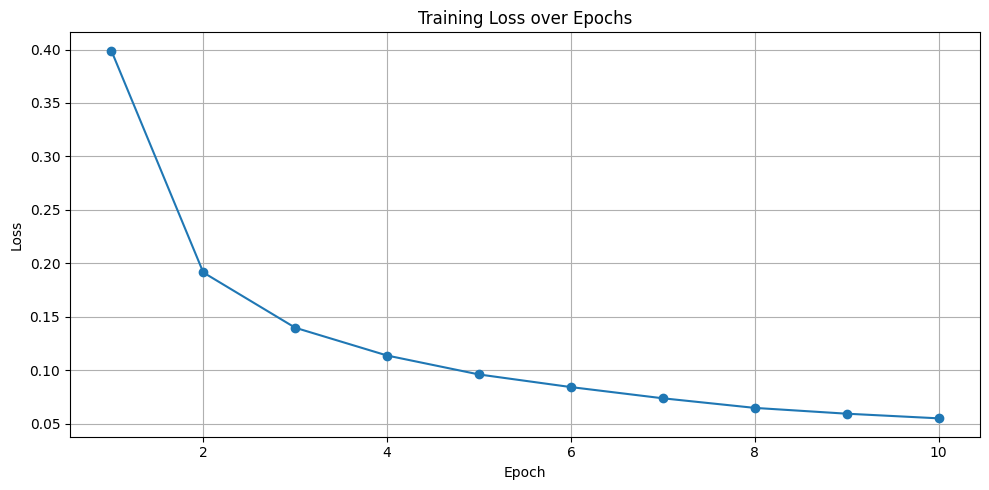

In [9]:

# ============================================================
# Step 8: Plot Training Loss
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker='o'
)

plt.title("Training Loss over Epochs")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.tight_layout()

plt.show()



# 📉 Step 8: Plot Training Loss

The loss curve helps visualize learning progress.

Good training behavior:
- steadily decreasing loss
- smooth convergence
- stable optimization


In [10]:

# ============================================================
# Step 9: Evaluate the Model
# ============================================================

correct = 0

total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predicted_values, predicted_labels = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted_labels == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 97.26%



# 🎯 Step 9: Evaluate the Model

After training, we test the model on unseen images.

The output neuron with the highest score becomes the predicted digit.

A fully connected MNIST model commonly achieves:
- 95% to 98% accuracy


In [11]:
# ============================================================
# Step 10: Save the Trained Model
# ============================================================

torch.save(
    model.state_dict(),
    "mnist_digit_classifier.pth"
)

print("✅ Model saved successfully!")
print("File name: mnist_digit_classifier.pth")

✅ Model saved successfully!
File name: mnist_digit_classifier.pth


In [12]:
# ============================================================
# Step 11: Load the Saved Model
# ============================================================

loaded_model = MNISTClassifier()

loaded_model.load_state_dict(
    torch.load("mnist_digit_classifier.pth")
)

loaded_model.eval()

print("✅ Saved model loaded successfully!")

✅ Saved model loaded successfully!


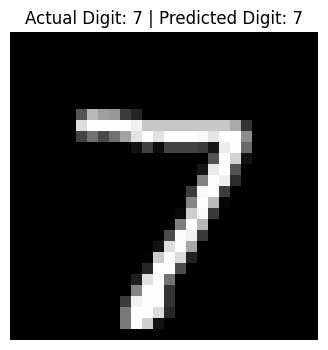

Actual Digit: 7
Predicted Digit: 7


In [13]:
# ============================================================
# Step 12: Predict Handwritten Digits
# ============================================================

# Get one test sample
sample_image, sample_label = test_dataset[0]

# Add batch dimension
sample_image_batch = sample_image.unsqueeze(0)

# Disable gradients during inference
with torch.no_grad():

    output_scores = loaded_model(sample_image_batch)

    predicted_digit = torch.argmax(
        output_scores,
        dim=1
    ).item()

# Display image
plt.figure(figsize=(4, 4))

plt.imshow(
    sample_image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Actual Digit: {sample_label} | "
    f"Predicted Digit: {predicted_digit}"
)

plt.axis("off")

plt.show()

print(f"Actual Digit: {sample_label}")

print(f"Predicted Digit: {predicted_digit}")